In [ ]:
!pip install nilearn openneuro-py


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.4 MB/s eta 0:00:00


In [ ]:
!openneuro-py download --dataset ds003643 --include "derivatives/sub-CN001/*" --target-dir "/content/ds003643-download/sub-CN001"  --verify-hash


👋 Hello! This is openneuro-py 2024.2.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds003643 …
📁 Traversing directories for ds003643 : 7310 entities [01:27, 83.11 entities/s] 
📥 Retrieving up to 14 files (5 concurrent downloads). 
participants.tsv:   0% 0.00/2.42k [00:00<?, ?B/s]
                                                 
sub-CN001_task-lppCN_run-05_space-MNIColin27_desc-preproc_bold.nii.gz:   0% 101k/73.8M [00:00<01:55, 670kB/s]
sub-CN001_task-lppCN_run-04_space-MNIColin27_desc-preproc_bold.nii.gz:   0% 0.00/63.8M [00:00<?, ?B/s]

sub-CN001_task-lppCN_run-06_space-MNIColin27_desc-preproc_bold.nii.gz:   0% 0.00/72.8M [00:00<?, ?B/s]


sub-CN001_task-lppCN_run-05_space-MNIColin27_desc-preproc_bold.nii.gz:   0% 339k/73.8M [00:00<00:56, 1.35MB/s]
sub-CN001_task-lppCN_run-04_space-MNIColin27_desc-preproc_bold.nii.gz:   0% 66.6k/63.8M [00:00<02:02, 545kB/s]

sub-CN001_task-lppCN_

In [ ]:
!openneuro-py download --dataset ds003643 --include "sub-CN001/*" --target-dir "/content/ds003643-download/sub-CN001"  --verify-hash

                                                                                                    
 Usage: openneuro-py download [OPTIONS]                                                             
                                                                                                    
 Download datasets from OpenNeuro.                                                                  
                                                                                                    
╭─ Options ────────────────────────────────────────────────────────────────────────────────────────╮
│ *  --dataset                                         TEXT     The OpenNeuro dataset identifier.  │
│                                                               [required]                         │
│    --tag                                             TEXT     The tag (version) of the dataset.  │
│    --target-dir                                      TEXT     The directory to download t

In [ ]:
import os
import numpy as np
import nibabel as nib
import nilearn
from nilearn import plotting, image
import matplotlib.pyplot as plt
import pandas as pd

Loading fMRI data...
Data shape: (73, 90, 74, 283)
TR: 2.0 seconds
Number of volumes: 283


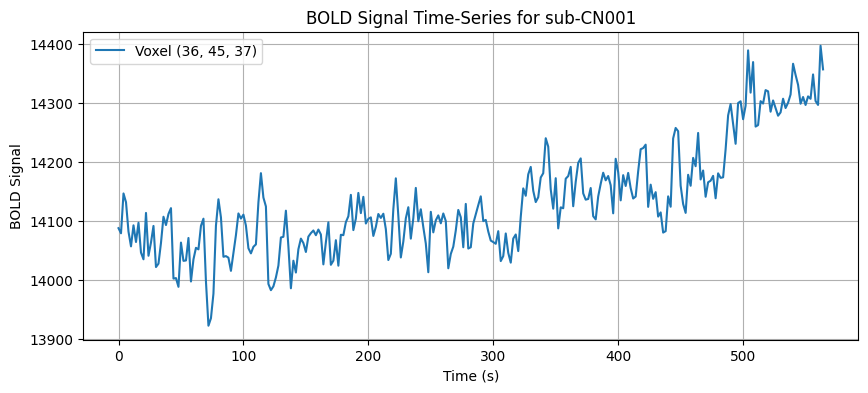

<ipython-input-21-7c1e32c62873>:47: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_img = image.mean_img(fmri_img)


<Figure size 800x600 with 0 Axes>

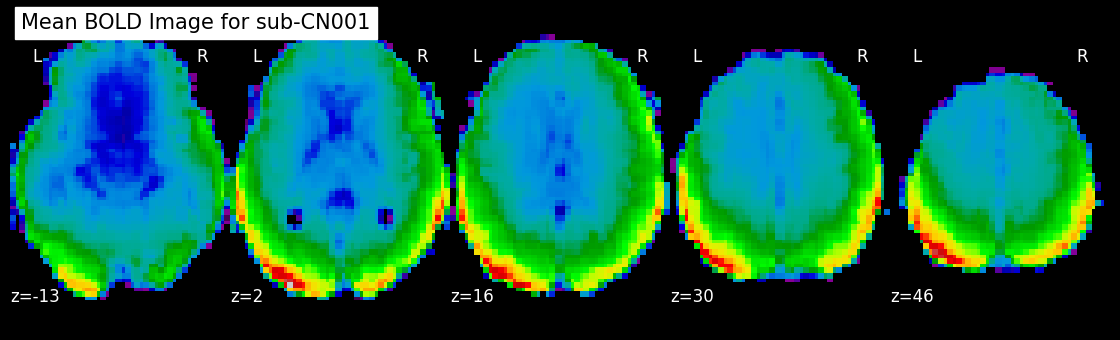

<Figure size 800x600 with 0 Axes>

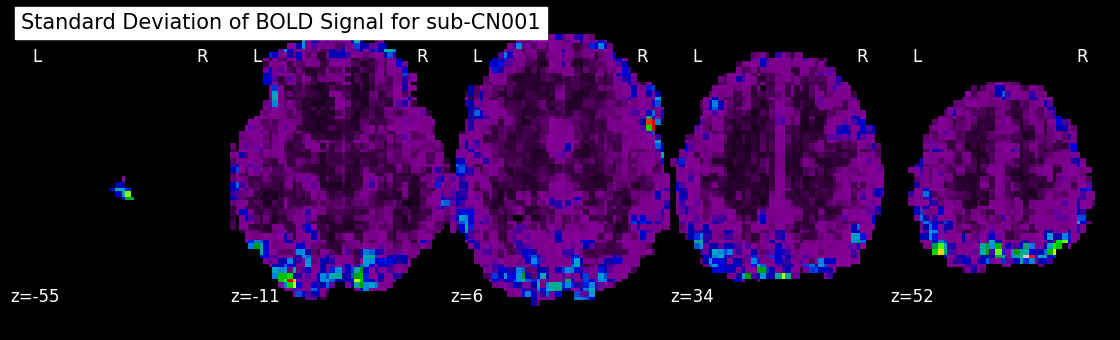

Mean BOLD signal across all voxels: 9516.91
Standard deviation of BOLD signal: 11541.99


[get_dataset_dir] Dataset found in /root/nilearn_data/fsl

AttributeError: module 'nilearn.image' has no attribute 'masked_extract'

In [ ]:
# Set base directory (adjust to your local path where dataset is downloaded)
base_dir = "/content/ds003643-download/"  # e.g., "C:/Users/YourName/ds003643-download"

# Example subject and task (adjust based on your dataset exploration)
subject = "sub-CN001"  # Replace with an actual subject ID from the dataset
task = "littleprince"  # Task name based on dataset description
func_file = os.path.join(base_dir, subject, "func", f"{subject}_task-{task}_bold.nii.gz")
motion_file = os.path.join(base_dir, "derivatives", subject, "func", f"{subject}_task-{task}_desc-confounds_timeseries.tsv")

func_file = "/content/ds003643-download/sub-CN001/derivatives/sub-CN001/func/sub-CN001_task-lppCN_run-04_space-MNIColin27_desc-preproc_bold.nii.gz"

# # Check if files exist
# if not os.path.exists(func_file):
#     raise FileNotFoundError(f"fMRI file not found: {func_file}")
# if not os.path.exists(motion_file):
#     print(f"Motion file not found at {motion_file}, skipping motion analysis.")


# --- 1. Load and Inspect fMRI Data ---
print("Loading fMRI data...")
fmri_img = nib.load(func_file)
data = fmri_img.get_fdata()  # 4D array: (x, y, z, time)
header = fmri_img.header
tr = header.get_zooms()[3]  # Repetition time (TR) in seconds
n_volumes = data.shape[3]   # Number of time points

print(f"Data shape: {data.shape}")
print(f"TR: {tr} seconds")
print(f"Number of volumes: {n_volumes}")

# --- 2. Extract and Plot BOLD Signal from a Sample Voxel ---
# Choose a voxel (e.g., center of the brain, adjust as needed)
x, y, z = data.shape[0] // 2, data.shape[1] // 2, data.shape[2] // 2
bold_signal = data[x, y, z, :]

plt.figure(figsize=(10, 4))
plt.plot(np.arange(n_volumes) * tr, bold_signal, label=f"Voxel ({x}, {y}, {z})")
plt.xlabel("Time (s)")
plt.ylabel("BOLD Signal")
plt.title(f"BOLD Signal Time-Series for {subject}")
plt.legend()
plt.grid(True)
plt.savefig("bold_signal.png")
plt.show()

# --- 3. Compute and Plot Mean BOLD Image ---
mean_img = image.mean_img(fmri_img)
plt.figure(figsize=(8, 6))
plotting.plot_epi(mean_img, title=f"Mean BOLD Image for {subject}", display_mode="z", cut_coords=5)
plt.savefig("mean_bold.png")
plt.show()

# # --- 4. Motion Parameters (if available) ---
# if os.path.exists(motion_file):
#     print("Loading motion parameters...")
#     confounds = pd.read_csv(motion_file, sep="\t")

#     # Common motion parameters: translations (mm) and rotations (radians)
#     motion_params = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
#     available_params = [p for p in motion_params if p in confounds.columns]

#     if available_params:
#         plt.figure(figsize=(10, 6))
#         for param in available_params:
#             plt.plot(confounds[param], label=param)
#         plt.xlabel("Volume")
#         plt.ylabel("Motion (mm or radians)")
#         plt.title(f"Motion Parameters for {subject}")
#         plt.legend()
#         plt.grid(True)
#         plt.savefig("motion_params.png")
#         plt.show()
#     else:
#         print("No standard motion parameters found in confounds file.")
# else:
#     print("Skipping motion analysis due to missing file.")

# --- 5. Basic Stats and Quality Check ---
# Compute standard deviation across time to check variability
std_img = image.math_img("np.std(img, axis=3)", img=fmri_img)
plt.figure(figsize=(8, 6))
plotting.plot_epi(std_img, title=f"Standard Deviation of BOLD Signal for {subject}", display_mode="z", cut_coords=5)
plt.savefig("std_bold.png")
plt.show()

# Summary stats
mean_signal = np.mean(data)
std_signal = np.std(data)
print(f"Mean BOLD signal across all voxels: {mean_signal:.2f}")
print(f"Standard deviation of BOLD signal: {std_signal:.2f}")


[get_dataset_dir] Dataset found in /root/nilearn_data/fsl

<ipython-input-23-6cd4b1e1a4fc>:14: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  roi_mask_resampled = image.resample_to_img(roi_mask, fmri_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


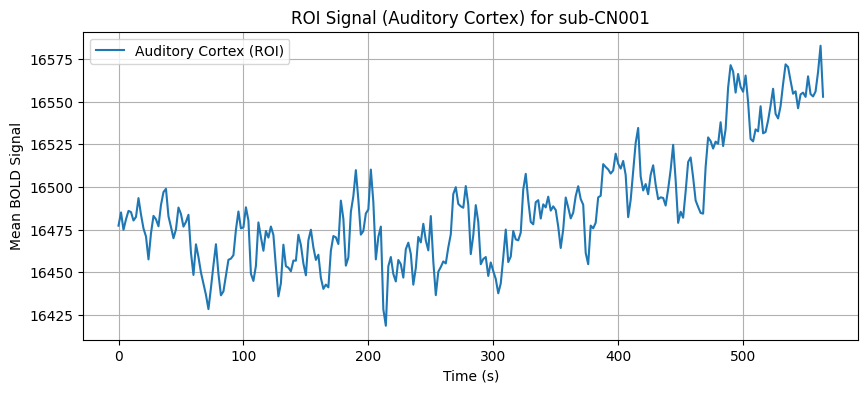

EDA complete. Plots saved as PNG files.


In [ ]:
# --- 6. Optional: ROI Signal Extraction (e.g., Auditory Cortex) ---
# Use a predefined atlas (e.g., Harvard-Oxford) for ROI
atlas = nilearn.datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas["maps"]

# Example: Extract signal from primary auditory cortex (adjust label index)
roi_label = 1  # Adjust based on atlas documentation
roi_mask = image.math_img(f"img == {roi_label}", img=atlas_img)

# Instead of image.masked_extract, use nilearn.masking.apply_mask:
from nilearn import image

# Resample the ROI mask to the fMRI image space
roi_mask_resampled = image.resample_to_img(roi_mask, fmri_img, interpolation='nearest')

# Now use the resampled mask:
roi_signal = masking.apply_mask(fmri_img, roi_mask_resampled)

if roi_signal.size > 0:
    mean_roi_signal = np.mean(roi_signal, axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(n_volumes) * tr, mean_roi_signal, label="Auditory Cortex (ROI)")
    plt.xlabel("Time (s)")
    plt.ylabel("Mean BOLD Signal")
    plt.title(f"ROI Signal (Auditory Cortex) for {subject}")
    plt.legend()
    plt.grid(True)
    plt.savefig("roi_signal.png")
    plt.show()
else:
    print("ROI extraction failed; check atlas alignment or mask.")

print("EDA complete. Plots saved as PNG files.")